# Final One-Time Test Evaluation

This notebook performs the single final evaluation of the fine-tuned MobileNetV2 on the reserved test split. The model, binary threshold, and human-review thresholds were fixed using training and validation data before this notebook was executed. No test result is used to modify the model or operating thresholds.

## Locked evaluation protocol

- Model: best controlled fine-tuning checkpoint.
- Binary threshold: loaded unchanged from the validation recalibration artifact.
- Human-review interval: loaded unchanged from the validation artifact.
- Test images are used only for final reporting.
- Results are reported without post-test adjustment.

In [1]:
from __future__ import annotations
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, average_precision_score, classification_report, confusion_matrix, f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve)

SEED = 42
IMAGE_SIZE = (224,224)
BATCH_SIZE = 16
PROJECT_ROOT = Path.cwd().resolve()
MANIFEST_PATH = PROJECT_ROOT/'data/processed/tile/manifests/tile_supervised_splits.csv'
MODEL_PATH = PROJECT_ROOT/'outputs/models/milestone4/mobilenetv2_finetuned_standard_best.keras'
VALIDATION_THRESHOLD_PATH = PROJECT_ROOT/'outputs/analysis/milestone5/fine_tuned_threshold_selection_summary.json'
ANALYSIS_DIR = PROJECT_ROOT/'outputs/analysis/milestone7'
FIGURE_DIR = PROJECT_ROOT/'outputs/figures/milestone7'
ANALYSIS_DIR.mkdir(parents=True,exist_ok=True); FIGURE_DIR.mkdir(parents=True,exist_ok=True)
tf.keras.utils.set_random_seed(SEED)
locked = json.loads(VALIDATION_THRESHOLD_PATH.read_text(encoding='utf-8'))
BINARY_THRESHOLD = float(locked['selected_binary_threshold'])
LOW_THRESHOLD = float(locked['human_review']['low_threshold'])
HIGH_THRESHOLD = float(locked['human_review']['high_threshold'])
print(f'Locked binary threshold: {BINARY_THRESHOLD:.9f}')
print(f'Locked human-review interval: [{LOW_THRESHOLD:.9f}, {HIGH_THRESHOLD:.9f})')

Locked binary threshold: 0.152666137
Locked human-review interval: [0.152666137, 0.439000000)


In [2]:
manifest = pd.read_csv(MANIFEST_PATH)
assert manifest.groupby('group_id')['split'].nunique().max() == 1
assert manifest.groupby('sha256')['split'].nunique().max() == 1
test = manifest.loc[manifest['split'].eq('test')].copy().reset_index(drop=True)
assert len(test) == 51
def load_image(path):
    image = tf.io.decode_png(tf.io.read_file(path),channels=3)
    return tf.cast(tf.image.resize(image,IMAGE_SIZE,antialias=True),tf.float32)
test_ds = tf.data.Dataset.from_tensor_slices(test['source_path'].astype(str).to_numpy()).map(load_image,num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
model = tf.keras.models.load_model(MODEL_PATH,compile=False)
y_true = test['binary_label'].astype(int).to_numpy()
probability = model.predict(test_ds,verbose=0).reshape(-1)
y_pred = (probability >= BINARY_THRESHOLD).astype(int)
print('Test images:',len(test)); display(pd.crosstab(test['binary_class'],columns='count'))

Test images: 51


col_0,count
binary_class,
defective,12
good,39


In [3]:
tn,fp,fn,tp = confusion_matrix(y_true,y_pred,labels=[0,1]).ravel()
metrics = {'threshold':BINARY_THRESHOLD,'tn':int(tn),'fp':int(fp),'fn':int(fn),'tp':int(tp),'accuracy':accuracy_score(y_true,y_pred),'precision':precision_score(y_true,y_pred,zero_division=0),'recall':recall_score(y_true,y_pred,zero_division=0),'f1':f1_score(y_true,y_pred,zero_division=0),'roc_auc':roc_auc_score(y_true,probability),'pr_auc':average_precision_score(y_true,probability)}
report = classification_report(y_true,y_pred,target_names=['good','defective'],output_dict=True,zero_division=0)
print(json.dumps(metrics,indent=2)); display(pd.DataFrame(report).T)

{
  "threshold": 0.1526661366224289,
  "tn": 38,
  "fp": 1,
  "fn": 2,
  "tp": 10,
  "accuracy": 0.9411764705882353,
  "precision": 0.9090909090909091,
  "recall": 0.8333333333333334,
  "f1": 0.8695652173913043,
  "roc_auc": 0.9743589743589745,
  "pr_auc": 0.9444444444444445
}


,precision,recall,f1-score,support
good,0.950000,0.974359,0.962025,39.000000
defective,0.909091,0.833333,0.869565,12.000000
accuracy,0.941176,0.941176,0.941176,0.941176
macro avg,0.929545,0.903846,0.915795,51.000000
weighted avg,0.940374,0.941176,0.940270,51.000000


In [4]:
decision = np.where(probability < LOW_THRESHOLD,'Good',np.where(probability >= HIGH_THRESHOLD,'Defective','Needs Human Review'))
results = test[['relative_path','source_path','binary_class','binary_label','defect_type']].copy()
results['predicted_probability_defective'] = probability
results['predicted_class_binary'] = np.where(y_pred==1,'defective','good')
results['final_decision'] = decision
results['true_label'] = results['binary_class']
results['correct_or_incorrect'] = np.where(y_pred==y_true,'correct','incorrect')
results['error_type'] = np.select([(y_true==0)&(y_pred==1),(y_true==1)&(y_pred==0)],['false_positive','false_negative'],default='correct')
review_mask = decision=='Needs Human Review'; auto_mask=~review_mask
auto_pred = np.where(decision[auto_mask]=='Defective',1,0)
human = {'review_count':int(review_mask.sum()),'review_rate':float(review_mask.mean()),'automatic_coverage':float(auto_mask.mean()),'automatic_accuracy':float((auto_pred==y_true[auto_mask]).mean()),'missed_defects_as_automatic_good':int(((decision=='Good')&(y_true==1)).sum()),'automatic_defective_precision':float(precision_score(y_true,decision=='Defective',zero_division=0))}
print('Human-review results:',json.dumps(human,indent=2)); display(results['final_decision'].value_counts().rename('count').to_frame()); display(results.loc[results.error_type.ne('correct'),['relative_path','defect_type','predicted_probability_defective','error_type','final_decision']])

Human-review results: {
  "review_count": 1,
  "review_rate": 0.0196078431372549,
  "automatic_coverage": 0.9803921568627451,
  "automatic_accuracy": 0.96,
  "missed_defects_as_automatic_good": 2,
  "automatic_defective_precision": 1.0
}


,count
final_decision,
Good,40
Defective,10
Needs Human Review,1


,relative_path,defect_type,predicted_probability_defective,error_type,final_decision
12,test/gray_stroke/004.png,gray_stroke,0.118979,false_negative,Good
17,test/rough/005.png,rough,0.047457,false_negative,Good
38,train/good/143.png,good,0.192360,false_positive,Needs Human Review


In [5]:
defective = results.loc[results.binary_label.eq(1)].copy()
per_defect = defective.groupby('defect_type').agg(image_count=('binary_label','size'),detected_count=('predicted_class_binary',lambda s:(s=='defective').sum()),mean_probability=('predicted_probability_defective','mean')).reset_index()
per_defect['recall'] = per_defect['detected_count']/per_defect['image_count']
display(per_defect)

,defect_type,image_count,detected_count,mean_probability,recall
0,crack,2,2,0.999730,1.0
1,glue_strip,3,3,0.977811,1.0
2,gray_stroke,2,1,0.397384,0.5
3,oil,3,3,0.997393,1.0
4,rough,2,1,0.481424,0.5


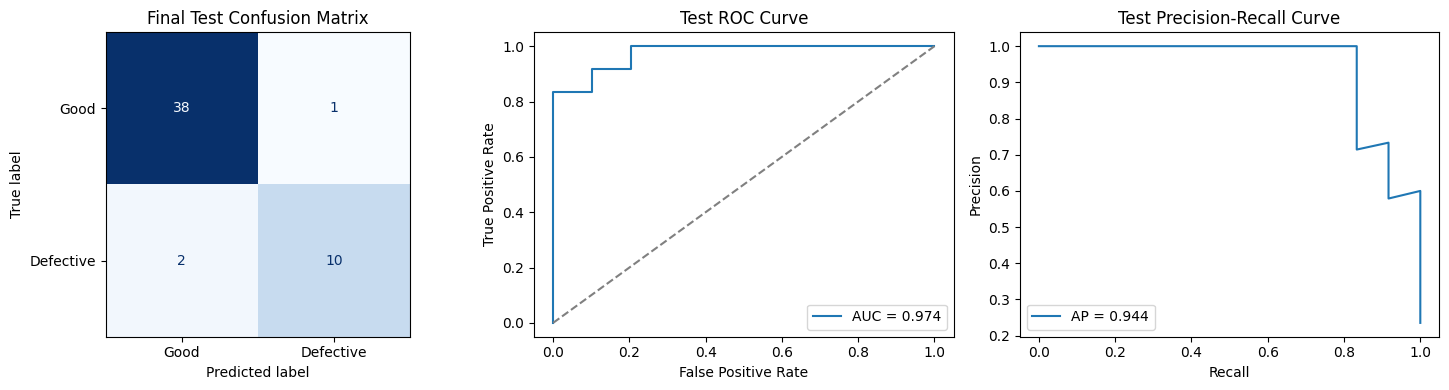

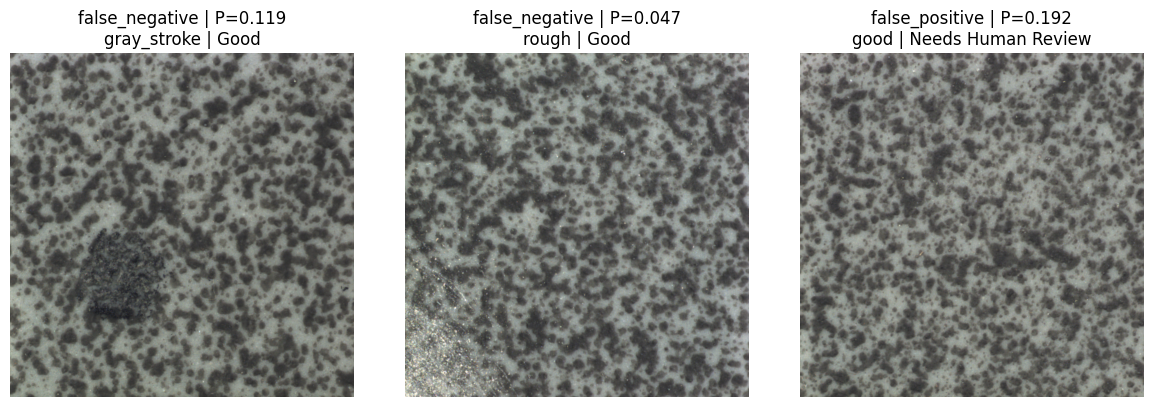

In [6]:
fig,axes=plt.subplots(1,3,figsize=(15,4))
ConfusionMatrixDisplay.from_predictions(y_true,y_pred,display_labels=['Good','Defective'],cmap='Blues',colorbar=False,ax=axes[0]); axes[0].set_title('Final Test Confusion Matrix')
fpr,tpr,_=roc_curve(y_true,probability); axes[1].plot(fpr,tpr,label=f"AUC = {metrics['roc_auc']:.3f}"); axes[1].plot([0,1],[0,1],'--',color='gray'); axes[1].set(title='Test ROC Curve',xlabel='False Positive Rate',ylabel='True Positive Rate'); axes[1].legend()
pc,rc,_=precision_recall_curve(y_true,probability); axes[2].plot(rc,pc,label=f"AP = {metrics['pr_auc']:.3f}"); axes[2].set(title='Test Precision-Recall Curve',xlabel='Recall',ylabel='Precision'); axes[2].legend()
fig.tight_layout(); fig.savefig(FIGURE_DIR/'final_test_metrics.png',dpi=160,bbox_inches='tight'); plt.show()
errors=results.loc[results.error_type.ne('correct')].copy()
if len(errors):
    cols=min(4,len(errors)); rows=int(np.ceil(len(errors)/cols)); fig2,axs=plt.subplots(rows,cols,figsize=(4*cols,4*rows),squeeze=False)
    for ax,(_,row) in zip(axs.flat,errors.iterrows()): ax.imshow(Image.open(row.source_path).convert('RGB')); ax.set_title(f"{row.error_type} | P={row.predicted_probability_defective:.3f}\n{row.defect_type} | {row.final_decision}"); ax.axis('off')
    for ax in axs.flat[len(errors):]: ax.axis('off')
    fig2.tight_layout(); fig2.savefig(FIGURE_DIR/'final_test_error_examples.png',dpi=160,bbox_inches='tight'); plt.show()
else: print('No binary-classification errors at the locked threshold.')

In [7]:
results.to_csv(ANALYSIS_DIR/'final_test_predictions_and_human_review.csv',index=False)
per_defect.to_csv(ANALYSIS_DIR/'final_test_per_defect_recall.csv',index=False)
pd.DataFrame(report).T.to_csv(ANALYSIS_DIR/'final_test_classification_report.csv')
summary={'evaluation_split':'test','evaluation_status':'final_one_time_evaluation','model':MODEL_PATH.name,'locked_validation_thresholds':{'binary_threshold':BINARY_THRESHOLD,'low_threshold':LOW_THRESHOLD,'high_threshold':HIGH_THRESHOLD},'test_images':len(test),'test_defective_images':int(y_true.sum()),'binary_metrics':metrics,'human_review':human,'test_used_for_tuning':False}
(ANALYSIS_DIR/'final_test_evaluation_summary.json').write_text(json.dumps(summary,indent=2),encoding='utf-8')
print(json.dumps(summary,indent=2))

{
  "evaluation_split": "test",
  "evaluation_status": "final_one_time_evaluation",
  "model": "mobilenetv2_finetuned_standard_best.keras",
  "locked_validation_thresholds": {
    "binary_threshold": 0.1526661366224289,
    "low_threshold": 0.1526661366224289,
    "high_threshold": 0.439
  },
  "test_images": 51,
  "test_defective_images": 12,
  "binary_metrics": {
    "threshold": 0.1526661366224289,
    "tn": 38,
    "fp": 1,
    "fn": 2,
    "tp": 10,
    "accuracy": 0.9411764705882353,
    "precision": 0.9090909090909091,
    "recall": 0.8333333333333334,
    "f1": 0.8695652173913043,
    "roc_auc": 0.9743589743589745,
    "pr_auc": 0.9444444444444445
  },
  "human_review": {
    "review_count": 1,
    "review_rate": 0.0196078431372549,
    "automatic_coverage": 0.9803921568627451,
    "automatic_accuracy": 0.96,
    "missed_defects_as_automatic_good": 2,
    "automatic_defective_precision": 1.0
  },
  "test_used_for_tuning": false
}


## Reporting rule

These test results must be reported as observed. The model or thresholds must not be revised in response to this evaluation without explicitly treating any subsequent experiment as a new development cycle with a new untouched holdout set.